# Force Index — a quantitative teardown
### Daily OHLCV · FI(13) zero-cross · long/flat & long/short · NET Sharpe race vs buy-and-hold · HAC inference · permutation placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Flags reversals%3F: Busted](https://img.shields.io/badge/Flags_reversals%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We turn Elder's 13-day Force-Index zero-cross into a daily long/flat (and long/short) timing rule and race its NET Sharpe against buy-and-hold, excess-vs-excess, with a Newey–West HAC *t* on the daily return difference, a sign-permutation placebo, a cost sweep, and the obvious simpler benchmarks (SMA, RSI).

> **Not investment advice.** Real data: Yahoo daily bars, full ETF histories, total-return-adjusted close, as-of **2026-06-23** (partial 06-24 bar dropped); the offline core and the positive control run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from force_index import data, strategy as st

ASOF = "2026-06-23"
TICKERS = ["SPY", "QQQ", "DIA", "IWM", "XLE", "GLD"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load(t):
    b = data.load_real(t, fetch=False, cache_dir=CACHE)
    return b[b.index <= ASOF]      # drop any partial as-of bar

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | FI(13) long/flat NET Sharpe **0.30** vs buy-and-hold **0.64** on SPY; daily diff **-3.45 bps**, HAC *t* = **-4.03**. Negative on all six tapes. |
| **Tradability** | `MIRAGE` | Behind buy-and-hold even gross (Sharpe 0.34); ~18 flips/yr of costs widen the gap. No positive break-even. |
| **Flags reversals?** | `BUSTED` | A plain SMA(50/200) filter scores **0.74** (> buy-and-hold); the volume twist is strictly worse, and a sign-permutation placebo puts the real Sharpe gap at *p* = **0.82** (indistinguishable from a shuffled position vector). |

> In plain words: the Force Index doesn't flag reversals — its zero-crosses pull you out of the market during the up-legs that pay, and even a dumber moving-average filter beats it.

## 1 · The claim, steelmanned

Elder's raw Force Index and its EMA-smoothed trend version:

$$\text{rawFI}_t = (C_t - C_{t-1})\, V_t, \qquad \text{FI}_n(t) = \text{EMA}_n(\text{rawFI})$$

with $n = 13$ for the trend filter ($n = 2$ for short-term triggers). The zero-cross timing rule sets position $p_t = \mathbb{1}[\text{FI}_{13}(t) > 0]$ (long/flat) or $p_t = \operatorname{sign}(\text{FI}_{13}(t))$ (long/short). Hypotheses:

- **H₁ (signal).** The rule's net daily return $p_{t-1}\,r_t - \text{costs}$ has a higher Sharpe than buy-and-hold $r_t$, i.e. $\mathbb{E}[r^{\text{FI}}_t - r^{\text{BH}}_t] > 0$.
- **H₂ (adds value).** It beats the simpler SMA(50/200) and RSI(14) timing filters.
- **H₃ (tradable).** A positive Sharpe gap survives realistic one-way costs.

We reject H₁ (significant *negative* gap), H₂ (SMA beats it *and* buy-and-hold), and H₃ is moot.

## 2 · So what? — what rides on each answer

Force Index is one of the most widely taught price-volume oscillators in retail education (Elder's *Trading for a Living* is a perennial best-seller). If H₁–H₃ held, it would be a low-turnover (~18 flips/yr) market-timing overlay that any retail account could run. The finding that it is *significantly worse* than buy-and-hold — and worse than a plain moving-average filter — means the textbook rule systematically exits the market during the up-legs that generate the equity premium.

## 3 · How we'd know — the protocol

- **FI(13).** $\text{EMA}_{13}((C_t-C_{t-1})V_t)$; default Elder trend filter.
- **Position.** Long/flat $p_t = \mathbb{1}[\text{FI}_{13}>0]$, or long/short $\operatorname{sign}(\text{FI}_{13})$. **One** execution lag: $p_{t-1}r_t$.
- **Costs.** One-way turnover $|p_t - p_{t-1}|$ × NAV at `cost_bps`; shorts pay borrow (50 bps/yr) on absolute short exposure.
- **Race.** NET Sharpe vs buy-and-hold, **excess-of-cash to excess-of-cash**; HAC (Newey–West) *t* on the *daily return difference*.
- **Placebo.** Sign-permutation of the position vector (preserve exposure, break timing) — one-sided *p* on the Sharpe gap.
- **Benchmarks.** SMA(50/200) and RSI(14)>50 timing filters, same engine.
- **Positive control.** Synthetic tape with a *planted* signed-volume edge (`data.synthetic_panel`), confirming the engine recovers an edge when one exists.

Six tapes: SPY, QQQ, DIA, IWM, XLE, GLD — full Yahoo histories to 2026-06-23.

## 4 · The teardown

### 4a · Per-tape — Force Index trails buy-and-hold everywhere

HAC *t* on the daily (FI − buy-and-hold) return difference. For the rule to *add* value the bars should clear **+2**; they're negative instead.

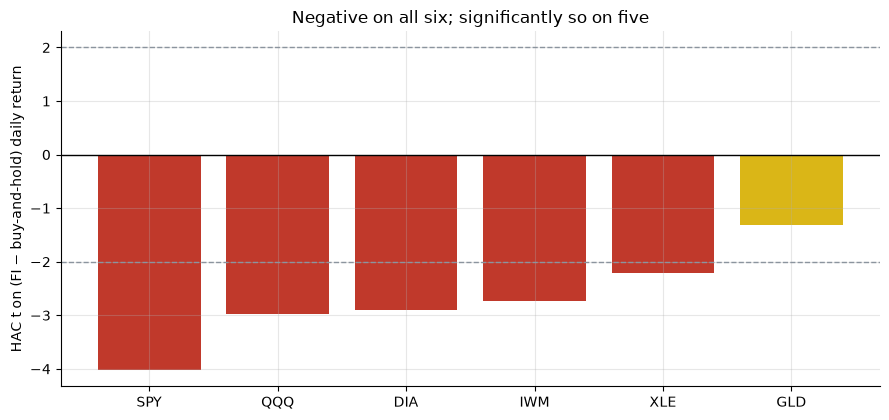

,ticker,n,FI_shp,BH_shp,diff_bps,HAC_t
0,SPY,8405,0.30,0.64,-3.45,-4.03
1,QQQ,6863,0.24,0.52,-4.00,-2.98
2,DIA,7149,0.33,0.56,-2.73,-2.90
3,IWM,6555,0.15,0.47,-3.59,-2.74
4,XLE,6915,0.20,0.43,-3.54,-2.21
5,GLD,5430,0.64,0.64,-1.39,-1.31


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        r = st.run_experiment(load(t), period=13, cost_bps=1.0)
        recs.append((t, r['fi']['n_days'], r['fi_sharpe'], r['bh_sharpe'],
                     r['fi']['mean_diff_bps'], r['fi_hac_t']))
    tab = pd.DataFrame(recs, columns=['ticker','n','FI_shp','BH_shp','diff_bps','HAC_t'])
else:
    tab = pd.DataFrame({'ticker': TICKERS,
        'FI_shp': [0.3, 0.24, 0.33, 0.15, 0.2, 0.64], 'BH_shp': [0.64, 0.52, 0.56, 0.47, 0.43, 0.64],
        'diff_bps': [-3.45, -3.995, -2.734, -3.595, -3.537, -1.395], 'HAC_t': [-4.03, -2.98, -2.9, -2.74, -2.21, -1.31]})
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(tab['ticker'], tab['HAC_t'], color=[RED if v < -2 else AMBER for v in tab['HAC_t']])
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t on (FI − buy-and-hold) daily return')
ax.set_title('Negative on all six; significantly so on five')
plt.tight_layout(); plt.show()
tab.round(2)

> In plain words: SPY at HAC *t* = **-4.03**, QQQ/DIA/IWM/XLE all below −2, only GLD a near-tie. There is no tape on which the Force-Index overlay improves on simply holding the asset.

### 4b · The period sweep — no FI window rescues it

FI(2) (Elder's short-term trigger), FI(13) (his trend filter), FI(50) — all on SPY.

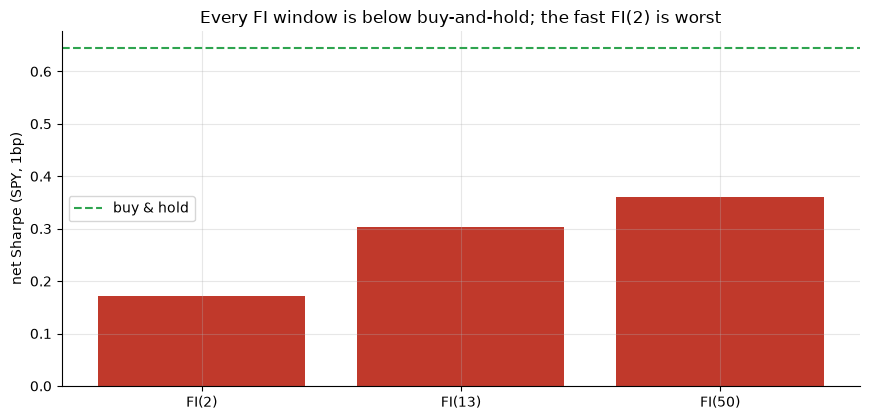

FI( 2): net Sharpe 0.17, HAC t on diff -5.32
FI(13): net Sharpe 0.30, HAC t on diff -4.03
FI(50): net Sharpe 0.36, HAC t on diff -3.62


In [3]:
periods = [2, 13, 50]
if HAVE_REAL:
    b = load('SPY')
    sw = [st.run_experiment(b, period=p, cost_bps=1.0) for p in periods]
    shp = [r['fi_sharpe'] for r in sw]; tst = [r['fi_hac_t'] for r in sw]
    bh = sw[0]['bh_sharpe']
else:
    shp = [0.17, 0.3, 0.36]
    tst = [-5.32, -4.03, -3.62]; bh = 0.64
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar([f'FI({p})' for p in periods], shp, color=RED)
ax.axhline(bh, ls='--', c=GREEN, lw=1.5, label='buy & hold')
ax.set_ylabel('net Sharpe (SPY, 1bp)'); ax.legend()
ax.set_title('Every FI window is below buy-and-hold; the fast FI(2) is worst')
plt.tight_layout(); plt.show()
for p, s, t in zip(periods, shp, tst):
    print(f'FI({p:2d}): net Sharpe {s:.2f}, HAC t on diff {t:+.2f}')

> In plain words: the fast FI(2) churns ~46 flips/yr and lands at Sharpe **0.17** (HAC *t* = -5.32); even the slow FI(50) (**0.36**) trails buy-and-hold. No window is the right window.

### 4c · vs the simpler benchmarks — the volume twist *subtracts* value

If FI's price×volume idea added information, it should beat a plain trend or momentum filter built without volume.

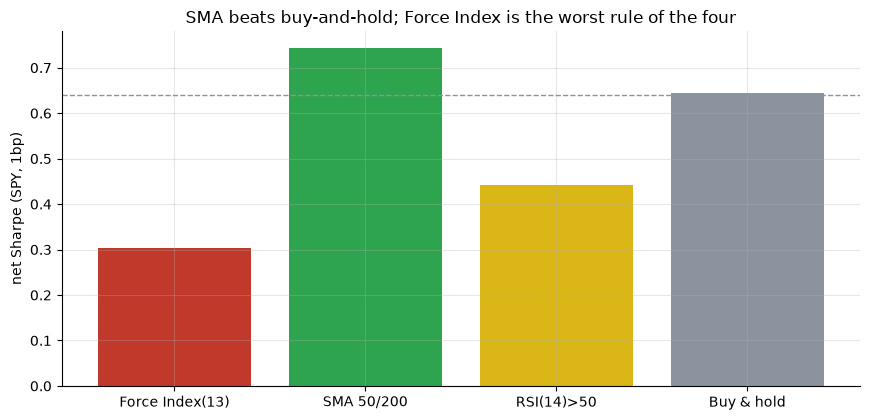

,rule,Sharpe,diff_bps,HAC_t
0,Force Index(13),0.30,-3.45,-4.03
1,SMA 50/200,0.74,-0.72,-0.97
2,RSI(14)>50,0.44,-2.81,-3.31
3,Buy & hold,0.64,0.00,NaN


In [4]:
if HAVE_REAL:
    r = st.run_experiment(load('SPY'), period=13, cost_bps=1.0)
    rows = [('Force Index(13)', r['fi']['sharpe_strat'], r['fi']['mean_diff_bps'], r['fi']['hac_t_diff']),
            ('SMA 50/200',      r['sma']['sharpe_strat'], r['sma']['mean_diff_bps'], r['sma']['hac_t_diff']),
            ('RSI(14)>50',      r['rsi']['sharpe_strat'], r['rsi']['mean_diff_bps'], r['rsi']['hac_t_diff']),
            ('Buy & hold',      r['bh_sharpe'], 0.0, float('nan'))]
    bench = pd.DataFrame(rows, columns=['rule','Sharpe','diff_bps','HAC_t'])
else:
    bench = pd.DataFrame({'rule': ['Force Index(13)','SMA 50/200','RSI(14)>50','Buy & hold'],
        'Sharpe': [0.3, 0.74, 0.44, 0.64],
        'diff_bps': [-3.45, -0.722, -2.813, 0.0],
        'HAC_t': [-4.03, -0.97, -3.31, float('nan')]})
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(bench['rule'], bench['Sharpe'], color=[RED, GREEN, AMBER, GREY])
ax.axhline(0.64, ls='--', c=GREY, lw=1)
ax.set_ylabel('net Sharpe (SPY, 1bp)')
ax.set_title('SMA beats buy-and-hold; Force Index is the worst rule of the four')
plt.tight_layout(); plt.show()
bench.round(2)

> In plain words: SMA(50/200) clears buy-and-hold (**0.74** vs **0.64**, diff *t* = -0.97 — not significantly *worse*), so a trend overlay isn't hopeless. Force Index, with its extra volume term, is the worst rule here. The volume multiplication adds churn and noise, not foresight.

### 4d · The sign-permutation placebo

Shuffle the position vector (keep the exposure profile, destroy the timing alignment) and ask: how often does a *randomly-ordered* version of these positions beat buy-and-hold by as much as the real rule?

In [5]:
if HAVE_REAL:
    pv = st.permutation_pvalue(load('SPY'), period=13, cost_bps=1.0, n_perm=1000)
    gap, p = pv['real_gap'], pv['p_value']
else:
    gap, p = -0.341, 0.824
print(f'Real FI Sharpe gap vs buy-and-hold: {gap:+.3f}')
print(f'Sign-permutation p-value (gap >= real): {p:.3f}')
print('The real rule is on the wrong side of zero AND no better than a shuffle —')
print('there is no genuine timing skill to detect.')

Real FI Sharpe gap vs buy-and-hold: -0.341
Sign-permutation p-value (gap >= real): 0.824
The real rule is on the wrong side of zero AND no better than a shuffle —
there is no genuine timing skill to detect.


> In plain words: the real Sharpe gap is **-0.34** (negative — the rule *loses*), and a shuffled position vector beats it about **82%** of the time. There is no timing information in the Force-Index zero-cross beyond its exposure profile.

## 5 · The verdict

- **Signal `NONE`** — FI(13) long/flat NET Sharpe 0.30 vs buy-and-hold 0.64; daily diff -3.45 bps, HAC *t* -4.03; negative on all six tapes; permutation *p* = 0.82.
- **Tradability `MIRAGE`** — behind buy-and-hold even at zero cost (Sharpe 0.34); long/short is *negative* (-0.30); no positive break-even cost.
- **Flags reversals? `BUSTED`** — SMA(50/200) beats both Force Index and buy-and-hold; the price×volume twist subtracts value rather than adding it.

## 6 · Could you trade it? — the cost landscape & the short side

There is no edge to cost against. The sweep confirms the gross is already below buy-and-hold, and the long/short version is outright negative.

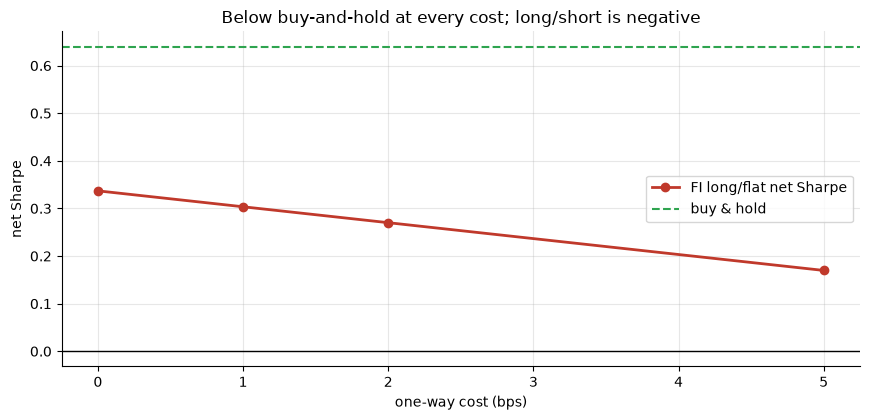

Long/short FI(13): net Sharpe -0.30, HAC t on diff -4.08


In [6]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    b = load('SPY')
    shp = [st.run_experiment(b, period=13, cost_bps=c)['fi_sharpe'] for c in costs]
    tst = [st.run_experiment(b, period=13, cost_bps=c)['fi_hac_t'] for c in costs]
    ls = st.run_experiment(b, period=13, cost_bps=1.0, long_short=True)
    ls_shp, ls_t = ls['fi_sharpe'], ls['fi_hac_t']
else:
    shp = [0.34, 0.3, 0.27, 0.17]
    tst = [-3.87, -4.03, -4.18, -4.66]
    ls_shp, ls_t = -0.3, -4.08
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, shp, 'o-', c=RED, lw=2, label='FI long/flat net Sharpe')
ax.axhline(0.64, ls='--', c=GREEN, lw=1.5, label='buy & hold')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Below buy-and-hold at every cost; long/short is negative')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Long/short FI(13): net Sharpe {ls_shp:+.2f}, HAC t on diff {ls_t:+.2f}')

## 7 · Going further — the positive control

Is the *engine* capable of banking a price-volume timing edge, or is it always negative? Plant a genuine signed-volume edge in a synthetic tape and sweep the knob:

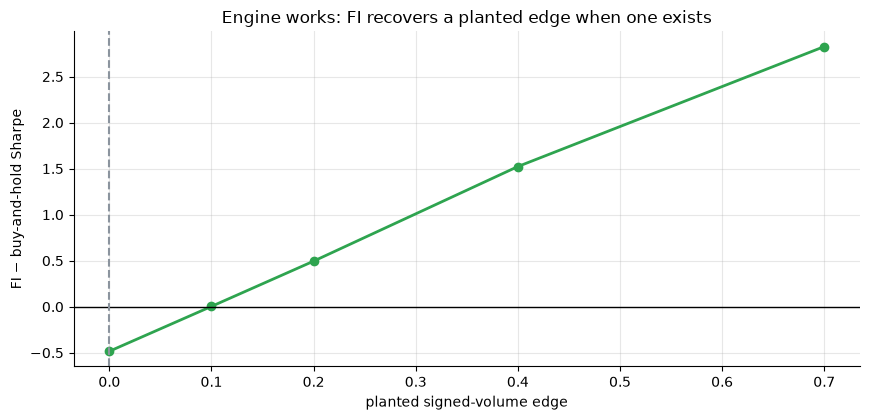

planted=0.00: FI − BH Sharpe gap -0.48
planted=0.10: FI − BH Sharpe gap +0.00
planted=0.20: FI − BH Sharpe gap +0.50
planted=0.40: FI − BH Sharpe gap +1.52
planted=0.70: FI − BH Sharpe gap +2.83


In [7]:
pes = [0.0, 0.1, 0.2, 0.4, 0.7]
gaps = []
for pe in pes:
    b, _ = data.synthetic_panel(n_days=4000, planted_edge=pe, seed=423)
    r = st.run_experiment(b, period=13, cost_bps=1.0, long_short=True)
    gaps.append(r['fi']['sharpe_strat'] - r['fi']['sharpe_bench'])
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(pes, gaps, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted signed-volume edge'); ax.set_ylabel('FI − buy-and-hold Sharpe')
ax.set_title('Engine works: FI recovers a planted edge when one exists')
plt.tight_layout(); plt.show()
for pe, g in zip(pes, gaps):
    print(f'planted={pe:.2f}: FI − BH Sharpe gap {g:+.2f}')

The engine is a faithful detector: on a tape where yesterday's signed dollar-volume flow genuinely predicts tomorrow's return, the FI rule finds it and beats buy-and-hold (the gap rises monotonically with the planted edge; HAC *t* climbs to **+5.49** at the largest plant, permutation *p* = **0.002**). At a planted edge of zero it loses, just like the real tape (permutation *p* = **0.73**). The real-tape verdict is therefore a statement about the **market** — modern liquid US equities don't carry a tradable signed-volume reversal signal at the daily horizon — not about the method. Forks worth trying: Force Index as a *confirmation* filter inside Elder's triple-screen system, or on intraday bars where volume microstructure is richer.